In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [4]:
model = load_model("../models/brain_tumor_cnn.keras")

print("✅ Model Loaded Successfully!")

✅ Model Loaded Successfully!


In [5]:
class_names = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

In [6]:
img_path = "../dataset/Brain tumor/Testing/glioma/Te-gl_0010.jpg"

In [8]:
import os

testing_folder = "../dataset/Brain tumor/Testing/glioma"

print(os.listdir(testing_folder)[:10])

['Te-gl_1.jpg', 'Te-gl_10.jpg', 'Te-gl_100.jpg', 'Te-gl_101.jpg', 'Te-gl_102.jpg', 'Te-gl_103.jpg', 'Te-gl_104.jpg', 'Te-gl_105.jpg', 'Te-gl_106.jpg', 'Te-gl_107.jpg']


In [10]:
img_path = "../dataset/Brain tumor/Testing/glioma/Te-gl_1.jpg"

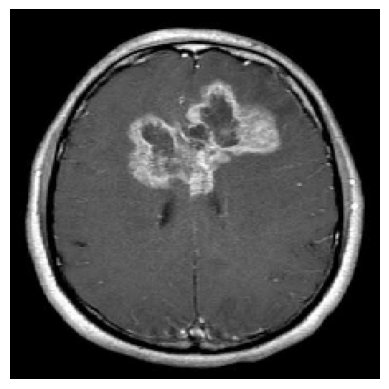

In [11]:
img = image.load_img(
    img_path,
    target_size=(224,224)
)

plt.imshow(img)
plt.axis("off")
plt.show()

In [12]:
img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)

(1, 224, 224, 3)


In [14]:
prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction)

print(f"Predicted Class: {class_names[predicted_class]}")
print(f"Confidence: {confidence*100:.2f}%")

print("\nClass Probabilities:\n")

for i, cls in enumerate(class_names):
    print(f"{cls:12}: {prediction[0][i]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted Class: No Tumor
Confidence: 57.52%

Class Probabilities:

Glioma      : 0.00%
Meningioma  : 42.48%
No Tumor    : 57.52%
Pituitary   : 0.00%
